# Lib


In [12]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

import warnings

warnings.filterwarnings("ignore")

# Data


In [8]:
# Load Labels
df_target = pd.read_csv("../../data/github_social_network/musae_git_target.csv")
df_target.columns = df_target.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Edges
df_edges = pd.read_csv("../../data/github_social_network/musae_git_edges.csv")
df_edges.columns = df_edges.columns.str.strip().str.lower().str.replace(" ", "_")

# Load Features
with open("../../data/github_social_network/musae_git_features.json", "r") as f:
    features_json = json.load(f)

In [11]:
print(f"Labels: {len(df_target)}")
print(f"Edges: {len(df_edges)}")
print(f"Features: {len(features_json)}")

Labels: 37700
Edges: 289003
Features: 37700


# EDA


In [ ]:
num_nodes = len(df_target)
num_edges = len(df_edges)

print(f"Tổng số lập trình viên (Nodes): {num_nodes:,}")
print(f"Tổng số quan hệ Follow (Edges): {num_edges:,}")

Tổng số lập trình viên (Nodes): 37,700
Tổng số quan hệ Follow (Edges): 289,003


In [ ]:
print(df_target.isnull().sum())
print()
print(df_edges.isnull().sum())

id           0
name         0
ml_target    0
dtype: int64

id_1    0
id_2    0
dtype: int64


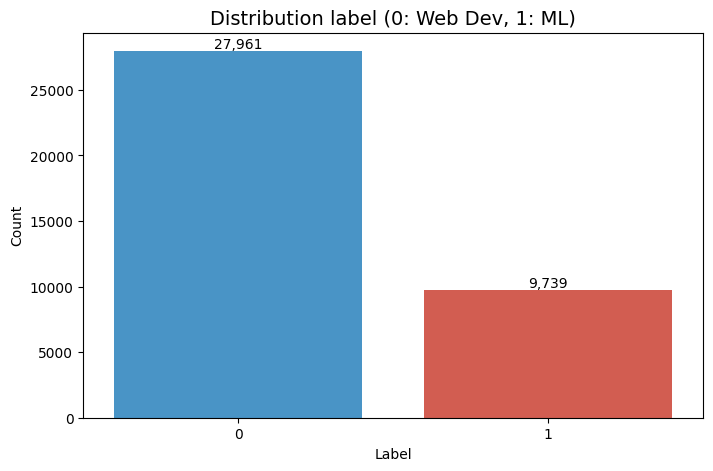

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_target, x="ml_target", palette=["#3498db", "#e74c3c"])
plt.title("Distribution label (0: Web Dev, 1: ML)", fontsize=14)
plt.ylabel("Count")
plt.xlabel("Label")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )

plt.show()

In [ ]:
ml_count = df_target["ml_target"].sum()
print("Distribution Label:")
print(
    f"\tML: {ml_count/num_nodes*100:.2f}%\n\tWeb Dev: {(num_nodes-ml_count)/num_nodes*100:.2f}%"
)

Distribution Label:
	ML: 25.83%
	Web Dev: 74.17%


# Graph inital

In [14]:
G = nx.Graph()

edges_list = list(zip(df_edges['id_1'], df_edges['id_2']))

G.add_edges_from(edges_list)

print(G)

Graph with 37700 nodes and 289003 edges


# Global Network Statistics

In [21]:
# Số lượng đỉnh và cạnh thực tế trong đồ thị
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

# Tính mật độ mạng (Density)
density = nx.density(G)

print(f"Số lượng đỉnh (Nodes): {num_nodes}")
print(f"Số lượng cạnh (Edges): {num_edges}")
print(f"Mật độ mạng (Density): {density:.5f}")

Số lượng đỉnh (Nodes): 37700
Số lượng cạnh (Edges): 289003
Mật độ mạng (Density): 0.00041


In [22]:
# Kiểm tra tính liên thông của đồ thị (Connectivity)
is_connected = nx.is_connected(G)
print(f"Đồ thị liên thông: {is_connected}")

Đồ thị liên thông: True


In [25]:
# Trích xuất Thành phần liên thông lớn nhất (Giant Connected Component)
if not is_connected:
    # Lấy danh sách các thành phần liên thông, sắp xếp giảm dần theo kích thước
    components = list(nx.connected_components(G))
    largest_component = max(components, key=len)
    
    # Tạo đồ thị con (subgraph) chỉ chứa các đỉnh của thành phần lớn nhất
    GCC = G.subgraph(largest_component).copy()
    
    print(f"Số lượng thành phần rời rạc: {len(components)}")
    print(f"Số lượng đỉnh trong Giant Connected Component (GCC): {GCC.number_of_nodes()}")
    print(f"Tỷ lệ đỉnh thuộc GCC: {(GCC.number_of_nodes() / num_nodes) * 100:.2f}%")
else:
    GCC = G
    print("Đồ thị là một khối liên thông duy nhất.")

Đồ thị là một khối liên thông duy nhất.


# Visualization

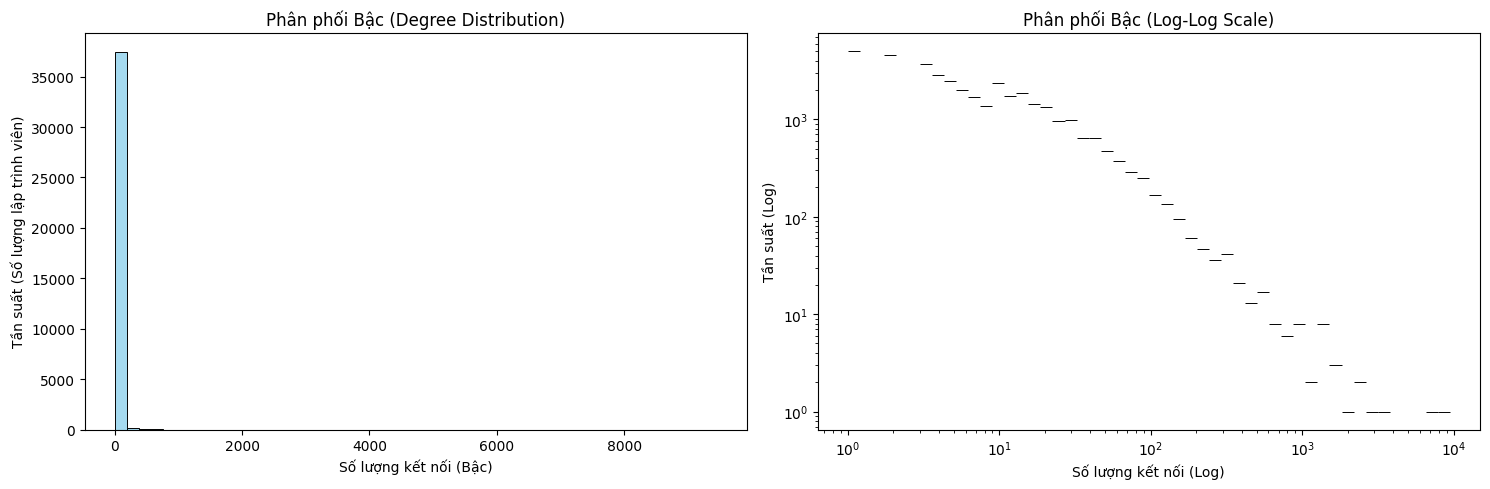

In [29]:
# Lấy danh sách bậc (số lượng người theo dõi lại) của từng đỉnh
degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(degrees, bins=50, kde=False, color='skyblue')
plt.title('Phân phối Bậc (Degree Distribution)')
plt.xlabel('Số lượng kết nối (Bậc)')
plt.ylabel('Tần suất (Số lượng lập trình viên)')

# Biểu đồ thang đo Log-Log (Đặc trưng của mạng xã hội - Power Law)
plt.subplot(1, 2, 2)
sns.histplot(degrees, bins=50, kde=False, color='coral', log_scale=(True, True))
plt.title('Phân phối Bậc (Log-Log Scale)')
plt.xlabel('Số lượng kết nối (Log)')
plt.ylabel('Tần suất (Log)')

plt.tight_layout()
plt.show()

In [30]:
# Trực quan hóa Ego-Graph (Mạng cục bộ của một nhân vật nổi bật)
# Tìm người có số lượng kết nối cao nhất
top_node = max(dict(G.degree()), key=dict(G.degree()).get)
top_degree = dict(G.degree())[top_node]

Tiến hành vẽ mạng cục bộ (Ego-graph) cho Node ID: 31890 (Sở hữu 9458 kết nối)


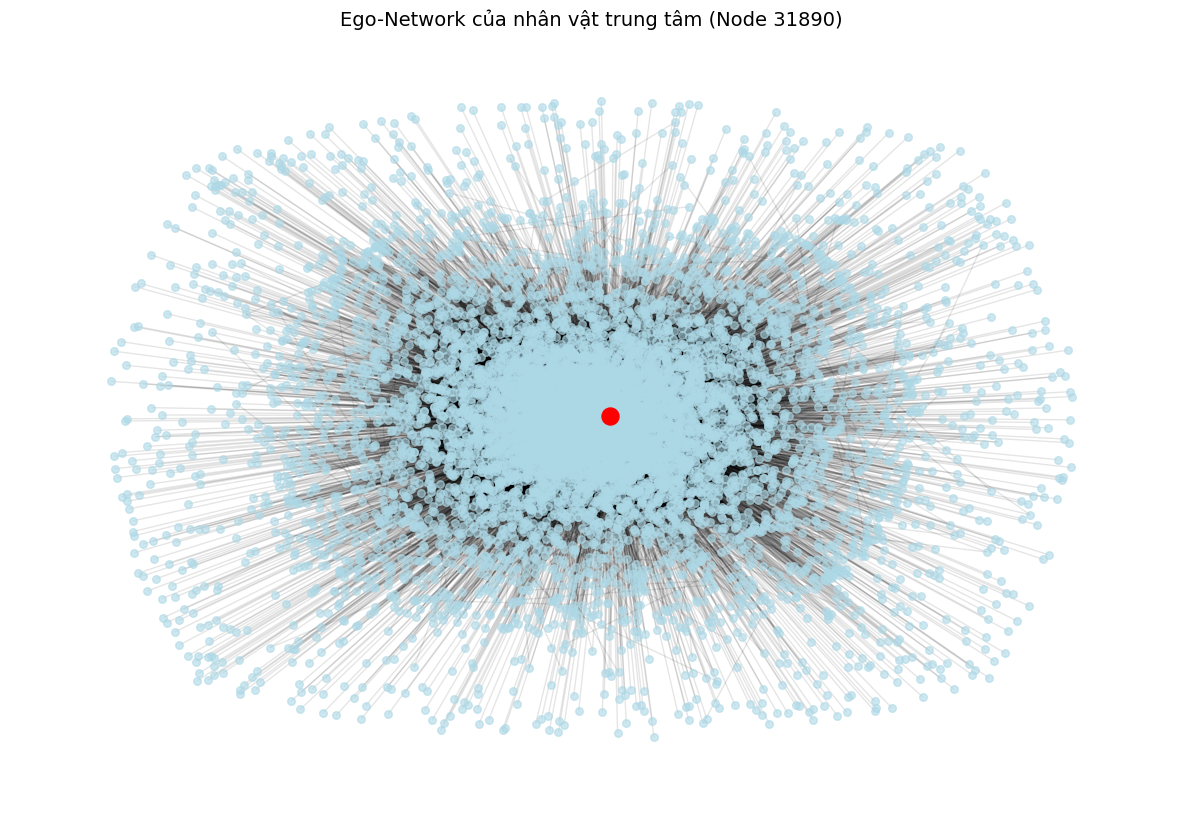

In [31]:
print(f"Tiến hành vẽ mạng cục bộ (Ego-graph) cho Node ID: {top_node} (Sở hữu {top_degree} kết nối)")

# Trích xuất ego-graph (Lấy đỉnh trung tâm và những người kết nối trực tiếp với nó)
# radius=1 nghĩa là chỉ lấy khoảng cách 1 bậc (bạn bè trực tiếp)
ego_G = nx.ego_graph(G, top_node, radius=1)
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(ego_G, seed=42)
nx.draw_networkx_nodes(ego_G, pos, node_color='lightblue', node_size=30, alpha=0.6)
nx.draw_networkx_nodes(ego_G, pos, nodelist=[top_node], node_color='red', node_size=150)
nx.draw_networkx_edges(ego_G, pos, alpha=0.1)
plt.title(f"Ego-Network của nhân vật trung tâm (Node {top_node})", fontsize=14)
plt.axis('off')
plt.show()